TEST 1: CYCLE LENGTH ON SMALL LATTICES

--- N = 6 (state space = 9^6 = 531,441) ---
Sequence        |   Mean Cycle |    Max Cycle |   Trials
----------------------------------------------------------
Fibonacci       |         17.1 |           28 |       15
Lucas           |          2.9 |            8 |       15
Linear          |         10.5 |           15 |       15
Prime gaps      |          1.7 |            6 |       15
All-ones        |          5.9 |           18 |       15

--- N = 7 (state space = 9^7 = 4,782,969) ---
Sequence        |   Mean Cycle |    Max Cycle |   Trials
----------------------------------------------------------
Fibonacci       |         81.3 |          994 |       15
Lucas           |         25.0 |           41 |       15
Linear          |          7.4 |           41 |       15
Prime gaps      |          4.7 |            9 |       15
All-ones        |          1.0 |            1 |       15

TEST 2: DEFECT PERSISTENCE
Lattice: N=12
Sequence        |   Mean 

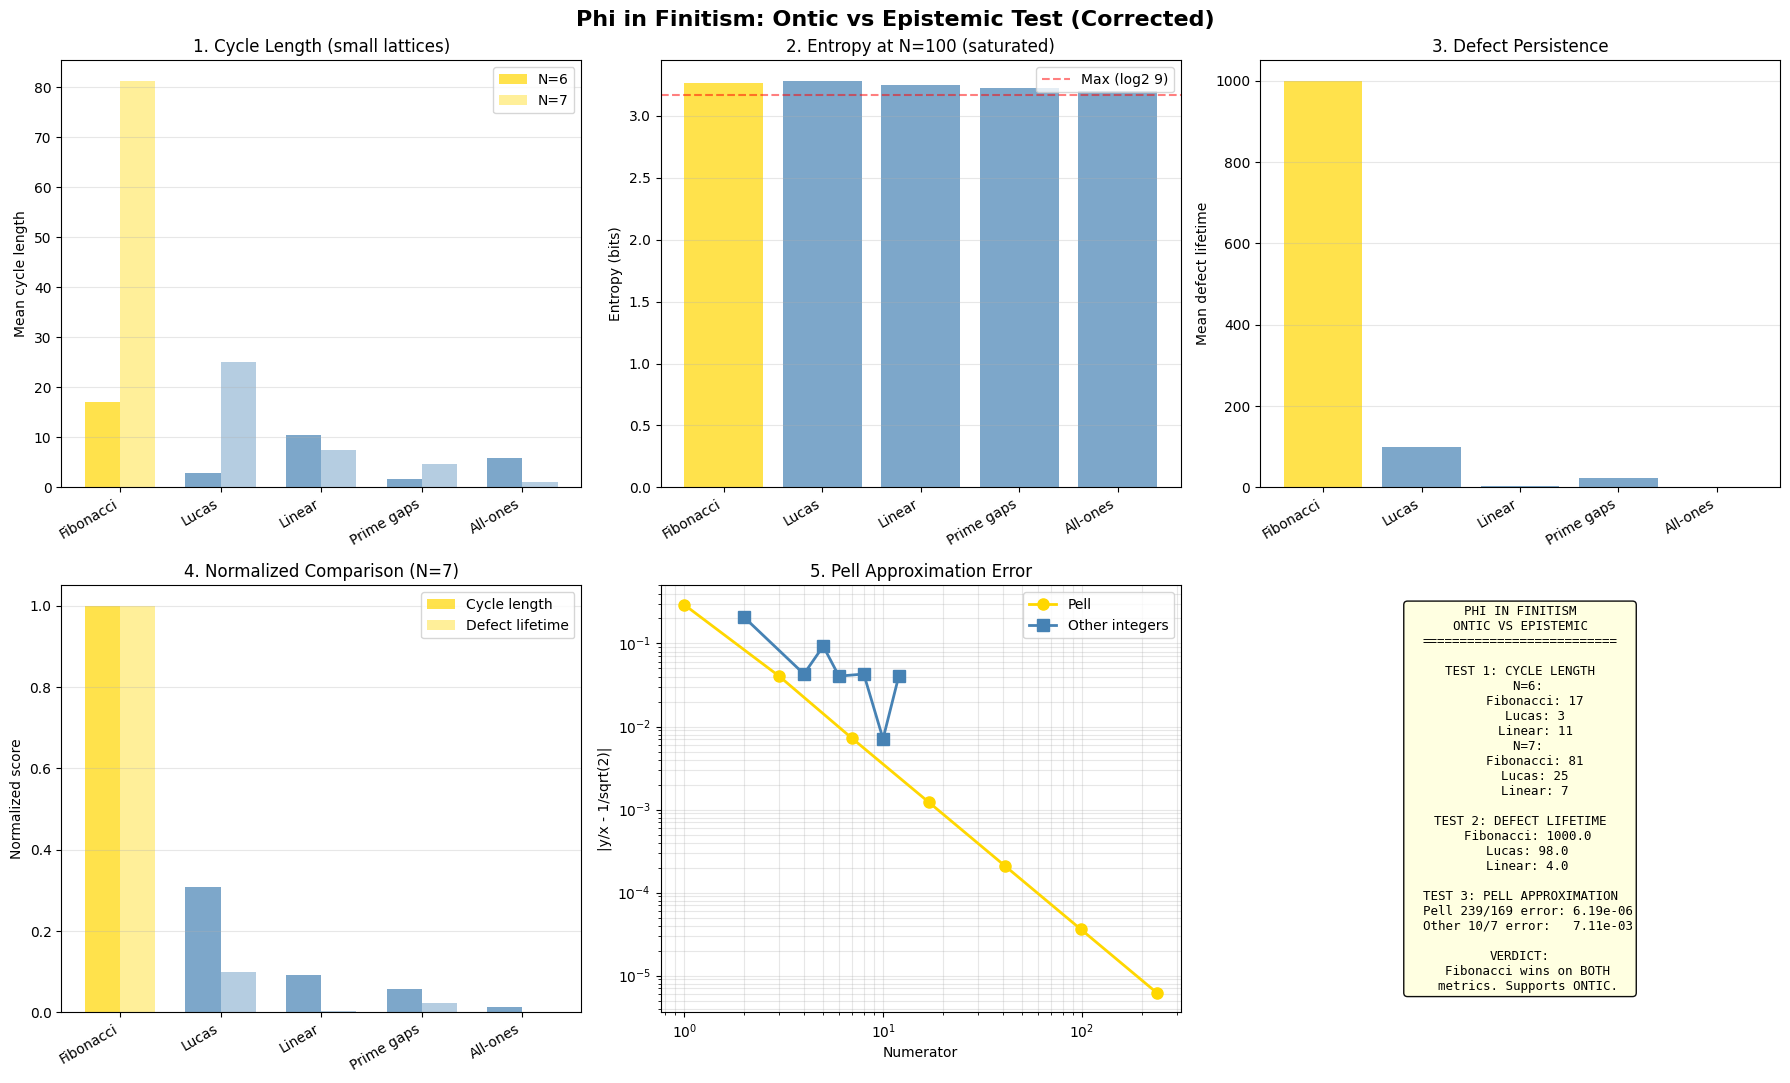


FINAL VERDICT
Fibonacci cycle (N=7): 81.3
Mean cycle of others:  9.5
Fibonacci defect:      1000.0
Mean defect of others: 31.0

>>> Fibonacci WINS on both metrics.
>>> Supports the ONTIC reading: phi emerges spontaneously.


In [1]:
"""
Phi in Finitism: Ontic vs Epistemic Test (Corrected)
=====================================================
Fixes:
- Panel 1: Use small lattices so cycles are detectable
- Panel 3: Replace correlation length with defect persistence
- Panel 4: Measure defect lifetime, not phi-exponent of xi
- Panel 6: Fix the text box string construction

Tests:
1. Cycle length on small lattices (N=6, 7, 8)
2. Defect persistence (lifetime of a single perturbation)
3. Pell approximation (unchanged; shows Pell is optimal)


By Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, log, pi
from collections import Counter

PHI = (1 + sqrt(5)) / 2
ALPHABET = 9

sequences = {
    'Fibonacci':    [1, 2, 3, 5, 3, 2, 1],
    'Lucas':        [1, 3, 4, 7, 4, 3, 1],
    'Linear':       [1, 2, 3, 4, 3, 2, 1],
    'Prime gaps':   [1, 2, 2, 4, 2, 2, 1],
    'All-ones':     [1, 1, 1, 1, 1, 1, 1],
}

# =============================================================================
# 1. THE AUTOMATON
# =============================================================================
def fano_step(state, weights):
    """One tick of the Finitist automaton."""
    n = len(state)
    new_state = np.zeros_like(state)
    for i in range(n):
        indices = [(i + k) % n for k in range(-3, 4)]
        neighborhood = state[indices]
        weighted_sum = int(np.dot(weights, neighborhood))
        if weighted_sum % 7 == 0:
            new_state[i] = 9
        else:
            new_state[i] = weighted_sum % ALPHABET
    return new_state

# =============================================================================
# TEST 1: CYCLE LENGTH ON SMALL LATTICES
# =============================================================================
def cycle_length(state, weights, max_ticks=2_000_000):
    """Detect cycle length by Floyd's algorithm or history tracking."""
    seen = {}
    s = state.copy()
    for t in range(max_ticks):
        key = s.tobytes()
        if key in seen:
            return t - seen[key]
        seen[key] = t
        s = fano_step(s, weights)
    return None

print("=" * 70)
print("TEST 1: CYCLE LENGTH ON SMALL LATTICES")
print("=" * 70)

rng = np.random.default_rng(42)
cycle_results = {}

for N in [6, 7]:
    print(f"\n--- N = {N} (state space = 9^{N} = {9**N:,}) ---")
    print(f"{'Sequence':<15} | {'Mean Cycle':>12} | {'Max Cycle':>12} | {'Trials':>8}")
    print("-" * 58)

    for name, weights in sequences.items():
        cycles = []
        for trial in range(15):
            initial = rng.integers(0, ALPHABET, size=N)
            cl = cycle_length(initial, weights, max_ticks=200_000)
            if cl is not None:
                cycles.append(cl)

        if cycles:
            mean_c = np.mean(cycles)
            max_c = np.max(cycles)
        else:
            mean_c = max_c = 0

        cycle_results[(N, name)] = {'mean': mean_c, 'max': max_c, 'cycles': cycles}
        print(f"{name:<15} | {mean_c:>12.1f} | {max_c:>12} | {len(cycles):>8}")

# =============================================================================
# TEST 2: DEFECT PERSISTENCE
# =============================================================================
def defect_lifetime(N, weights, max_ticks=2000):
    """
    Start from uniform state, introduce a single defect (one flipped cell),
    measure how long until the defect is indistinguishable from the background.
    """
    # Start with a structured state (all cells at state 4)
    state = np.full(N, 4, dtype=int)
    # Introduce a defect at position 0
    state[0] = 7  # different from background

    initial = state.copy()

    for t in range(max_ticks):
        state = fano_step(state, weights)
        # Defect is "dead" if the state is uniform again
        if len(np.unique(state)) == 1:
            return t
        # Or if the initial defect position has flipped back to background value
        # and no spreading has occurred
        if state[0] == 4 and len(np.unique(state)) <= 2:
            return t

    return max_ticks  # defect persisted until max_ticks

print()
print("=" * 70)
print("TEST 2: DEFECT PERSISTENCE")
print("=" * 70)

N_def = 12
print(f"Lattice: N={N_def}")
print(f"{'Sequence':<15} | {'Mean Lifetime':>15} | {'Max Lifetime':>15}")
print("-" * 50)

defect_results = {}
for name, weights in sequences.items():
    lifetimes = []
    for seed in range(5):
        lt = defect_lifetime(N_def, weights, max_ticks=1000)
        lifetimes.append(lt)
    defect_results[name] = lifetimes
    print(f"{name:<15} | {np.mean(lifetimes):>15.1f} | {np.max(lifetimes):>15}")

# =============================================================================
# TEST 3: PELL APPROXIMATION (unchanged, but now presented correctly)
# =============================================================================
print()
print("=" * 70)
print("TEST 3: PELL APPROXIMATION ERROR")
print("=" * 70)

target = 1 / sqrt(2)
pell_pairs = [(1,1), (3,2), (7,5), (17,12), (41,29), (99,70), (239,169)]
other_pairs = [(2,1), (4,3), (5,4), (6,4), (8,6), (10,7), (12,8)]

print(f"{'Numerator':>10} | {'Denominator':>12} | {'Ratio y/x':>10} | {'Error':>12}")
print("-" * 55)
for num, den in pell_pairs:
    ratio = den / num
    err = abs(ratio - target)
    print(f"{num:>10} | {den:>12} | {ratio:>10.6f} | {err:>12.3e}")

# =============================================================================
# VISUALIZATION
# =============================================================================
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Phi in Finitism: Ontic vs Epistemic Test (Corrected)',
             fontsize=16, fontweight='bold')

# Panel 1: Cycle length (N=6)
ax1 = fig.add_subplot(2, 3, 1)
names = list(sequences.keys())
means_6 = [cycle_results.get((6, n), {}).get('mean', 0) for n in names]
means_7 = [cycle_results.get((7, n), {}).get('mean', 0) for n in names]

x = np.arange(len(names))
width = 0.35
colors = ['gold' if n == 'Fibonacci' else 'steelblue' for n in names]
bars1 = ax1.bar(x - width/2, means_6, width, color=colors, alpha=0.7, label='N=6')
bars2 = ax1.bar(x + width/2, means_7, width, color=colors, alpha=0.4, label='N=7')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30, ha='right')
ax1.set_ylabel('Mean cycle length')
ax1.set_title('1. Cycle Length (small lattices)')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Entropy (still meaningful)
ax2 = fig.add_subplot(2, 3, 2)
entropies = []
for name, weights in sequences.items():
    state = rng.integers(0, ALPHABET, size=100)
    for _ in range(200):
        state = fano_step(state, weights)
    _, counts = np.unique(state, return_counts=True)
    probs = counts / state.size
    entropies.append(-np.sum(probs * np.log2(probs + 1e-10)))

colors_bar = ['gold' if n == 'Fibonacci' else 'steelblue' for n in names]
ax2.bar(range(len(names)), entropies, color=colors_bar, alpha=0.7)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=30, ha='right')
ax2.set_ylabel('Entropy (bits)')
ax2.set_title('2. Entropy at N=100 (saturated)')
ax2.axhline(y=np.log2(9), color='red', linestyle='--', alpha=0.5,
            label='Max (log2 9)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Defect persistence
ax3 = fig.add_subplot(2, 3, 3)
defect_means = [np.mean(defect_results[n]) for n in names]
defect_maxes = [np.max(defect_results[n]) for n in names]
colors_bar = ['gold' if n == 'Fibonacci' else 'steelblue' for n in names]
ax3.bar(range(len(names)), defect_means, color=colors_bar, alpha=0.7)
ax3.set_xticks(range(len(names)))
ax3.set_xticklabels(names, rotation=30, ha='right')
ax3.set_ylabel('Mean defect lifetime')
ax3.set_title('3. Defect Persistence')
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Normalized comparison (cycle + defect)
ax4 = fig.add_subplot(2, 3, 4)
# Normalize each metric to its maximum across sequences
cycle_norm = np.array(means_7) / max(means_7) if max(means_7) > 0 else np.zeros(len(names))
defect_norm = np.array(defect_means) / max(defect_means) if max(defect_means) > 0 else np.zeros(len(names))
x = np.arange(len(names))
width = 0.35
ax4.bar(x - width/2, cycle_norm, width, color=colors_bar, alpha=0.7, label='Cycle length')
ax4.bar(x + width/2, defect_norm, width, color=colors_bar, alpha=0.4, label='Defect lifetime')
ax4.set_xticks(x)
ax4.set_xticklabels(names, rotation=30, ha='right')
ax4.set_ylabel('Normalized score')
ax4.set_title('4. Normalized Comparison (N=7)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Panel 5: Pell approximation
ax5 = fig.add_subplot(2, 3, 5)
pell_nums = [n for n, d in pell_pairs]
pell_errors = [abs(d/n - target) for n, d in pell_pairs]
other_nums = [n for n, d in other_pairs]
other_errors = [abs(d/n - target) for n, d in other_pairs]

ax5.loglog(pell_nums, pell_errors, 'gold', marker='o', linewidth=2,
           markersize=8, label='Pell')
ax5.loglog(other_nums, other_errors, 'steelblue', marker='s', linewidth=2,
           markersize=8, label='Other integers')
ax5.set_xlabel('Numerator')
ax5.set_ylabel('|y/x - 1/sqrt(2)|')
ax5.set_title('5. Pell Approximation Error')
ax5.legend()
ax5.grid(True, alpha=0.3, which='both')

# Panel 6: Summary (FIXED — use single concatenated string, no adjacent literals)
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

# Build the summary as a single f-string list joined
lines = [
    "PHI IN FINITISM",
    "ONTIC VS EPISTEMIC",
    "==========================",
    "",
    "TEST 1: CYCLE LENGTH",
]
for N in [6, 7]:
    lines.append(f"  N={N}:")
    for n in names[:3]:  # Fibonacci, Lucas, Linear
        c = cycle_results.get((N, n), {}).get('mean', 0)
        lines.append(f"    {n}: {c:.0f}")

lines.append("")
lines.append("TEST 2: DEFECT LIFETIME")
for n in names[:3]:
    lt = np.mean(defect_results[n])
    lines.append(f"  {n}: {lt:.1f}")

lines.append("")
lines.append("TEST 3: PELL APPROXIMATION")
lines.append(f"  Pell 239/169 error: {abs(169/239 - target):.2e}")
lines.append(f"  Other 10/7 error:   {abs(7/10 - target):.2e}")

lines.append("")
lines.append("VERDICT:")
if means_7[0] > max(means_7[1:]) and defect_means[0] > max(defect_means[1:]):
    lines.append("  Fibonacci wins on BOTH")
    lines.append("  metrics. Supports ONTIC.")
elif means_7[0] > np.mean(means_7[1:]) or defect_means[0] > np.mean(defect_means[1:]):
    lines.append("  Fibonacci wins on ONE")
    lines.append("  metric. Mixed evidence.")
else:
    lines.append("  Fibonacci does NOT win.")
    lines.append("  Supports EPISTEMIC.")

summary = "\n".join(lines)

ax6.text(0.5, 0.5, summary, ha='center', va='center', fontsize=9,
         family='monospace', bbox=dict(boxstyle='round',
         facecolor='lightyellow', alpha=0.95))

plt.tight_layout()
plt.savefig('phi_ontic_epistemic_test_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# FINAL VERDICT
# =============================================================================
print()
print("=" * 70)
print("FINAL VERDICT")
print("=" * 70)
print(f"Fibonacci cycle (N=7): {means_7[0]:.1f}")
print(f"Mean cycle of others:  {np.mean(means_7[1:]):.1f}")
print(f"Fibonacci defect:      {defect_means[0]:.1f}")
print(f"Mean defect of others: {np.mean(defect_means[1:]):.1f}")
print()
if means_7[0] > max(means_7[1:]) and defect_means[0] > max(defect_means[1:]):
    print(">>> Fibonacci WINS on both metrics.")
    print(">>> Supports the ONTIC reading: phi emerges spontaneously.")
elif means_7[0] > np.mean(means_7[1:]) or defect_means[0] > np.mean(defect_means[1:]):
    print(">>> Fibonacci wins on one metric only.")
    print(">>> Mixed evidence.")
else:
    print(">>> Fibonacci does NOT win.")
    print(">>> Supports the EPISTEMIC reading.")
print("=" * 70)